In [1]:
import os
from glob import glob

import matplotlib.pyplot as plt
import torch

from Generator import *

In [2]:
DIV2K_PATH = "./datasets/DIV2K"
TRAIN_IMAGES = glob(os.path.join(DIV2K_PATH, "DIV2K_train_HR", "*.png"))
VAL_IMAGES = glob(os.path.join(DIV2K_PATH, "DIV2K_valid_HR", "*.png"))



=== DIV2K Dataset Analysis ===

Training images: 800
Validation images: 100
Total images: 900

Size range:
  Height: 768 - 2040px
  Width: 1140 - 2040px

Sample images:


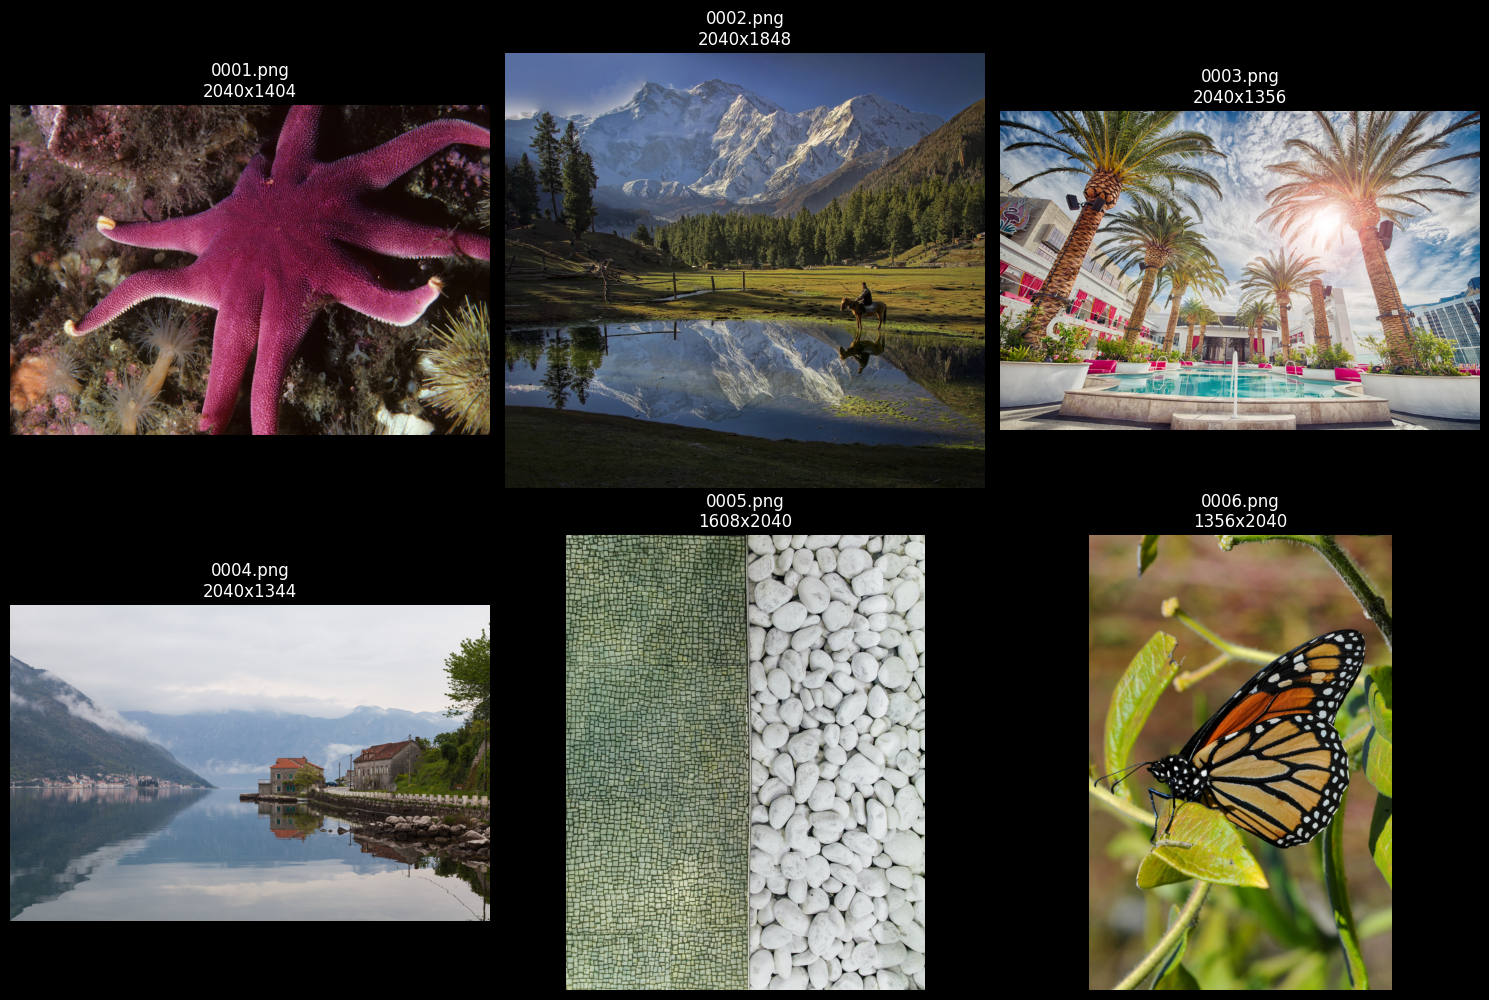

In [3]:
# Dataset Analysis
print("=== DIV2K Dataset Analysis ===\n")

# Count images
print(f"Training images: {len(TRAIN_IMAGES)}")
print(f"Validation images: {len(VAL_IMAGES)}")
print(f"Total images: {len(TRAIN_IMAGES) + len(VAL_IMAGES)}\n")

if len(TRAIN_IMAGES) == 0:
    print("WARNING: No training images found!")
else:
    # Analyze image dimensions
    train_sizes = []
    for img_path in TRAIN_IMAGES[:50]:  # Sample first 50 for speed
        img = cv.imread(img_path)
        if img is not None:
            train_sizes.append(img.shape[:2])  # (height, width)

    heights, widths = zip(*train_sizes)

    print(f"Size range:")
    print(f"  Height: {min(heights)} - {max(heights)}px")
    print(f"  Width: {min(widths)} - {max(widths)}px\n")

# Display sample images
print("Sample images:")
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, ax in enumerate(axes.flat):
    if i < len(TRAIN_IMAGES):
        img = cv.imread(TRAIN_IMAGES[i])
        if img is not None:
            img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
            ax.imshow(img_rgb)
            ax.set_title(f"{os.path.basename(TRAIN_IMAGES[i])}\n{img.shape[1]}x{img.shape[0]}")
            ax.axis('off')

plt.tight_layout()
plt.show()

In [4]:
print("Random text generation:")
print(string.ascii_letters + " " + string.digits)

print("Random text: ", random_text(min_len=10, max_len=50))

Random text generation:
abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ 0123456789
Random text:  bo tCdNRD30nby3s b7r


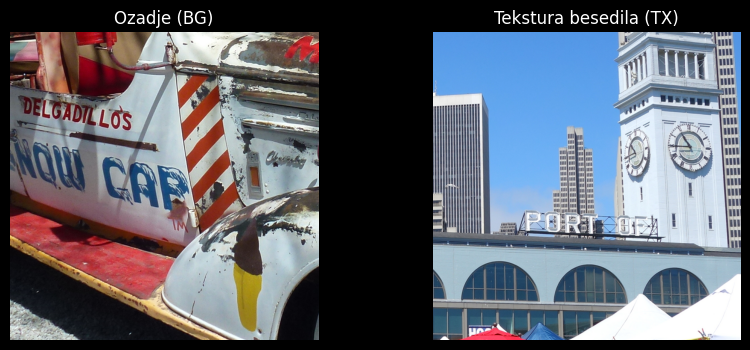

In [5]:
# TEST 1: Naložimo ozadje in teksturo

bg_path = random.choice(TRAIN_IMAGES)
tx_path = random.choice(TRAIN_IMAGES)

bg = cv.imread(bg_path)
tx = cv.imread(tx_path)

bg = random_crop(bg, GEN_SIZE)
tx = random_crop(tx, GEN_SIZE)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("Ozadje (BG)")
plt.imshow(cv.cvtColor(bg, cv.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Tekstura besedila (TX)")
plt.imshow(cv.cvtColor(tx, cv.COLOR_BGR2RGB))
plt.axis("off")

plt.show()

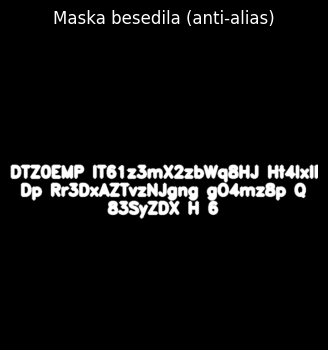

Maska: (512, 512, 1)


In [6]:
# TEST 2: Generiranje maske besedila

mask = generate_text_mask(GEN_SIZE, min_len=50, max_len=100)

plt.figure(figsize=(4, 4))
plt.title("Maska besedila (anti-alias)")
plt.imshow(mask[:, :, 0], cmap="gray")
plt.axis("off")
plt.show()

print("Maska:", mask.shape)


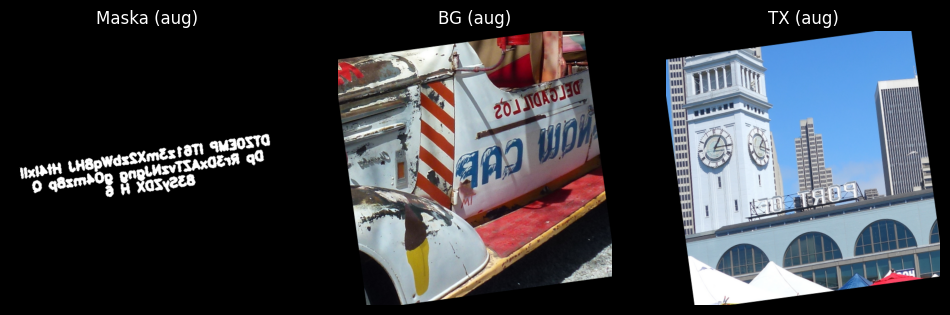

In [7]:
# TEST 3: Augmentacija maske, bg in teksture

angle = random.uniform(-15, 15)
scale = random.uniform(0.9, 1.1)
flip = True

mask_aug = augment_affine(mask, angle, scale, flip)
bg_aug = augment_affine(bg.astype(np.float32), angle, scale, flip)
tx_aug = augment_affine(tx.astype(np.float32), angle, scale, flip)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Maska (aug)")
plt.imshow(mask_aug[:, :, 0], cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("BG (aug)")
plt.imshow(cv.cvtColor(bg_aug.astype(np.uint8), cv.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("TX (aug)")
plt.imshow(cv.cvtColor(tx_aug.astype(np.uint8), cv.COLOR_BGR2RGB))
plt.axis("off")

plt.show()


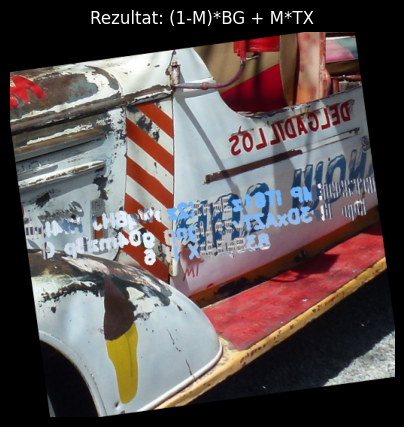

In [8]:
# TEST 4: Aplikacija maske s teksturo na ozadje

composed = apply_text_texture(bg_aug, tx_aug, mask_aug)

plt.figure(figsize=(5, 5))
plt.title("Rezultat: (1-M)*BG + M*TX")
plt.imshow(cv.cvtColor(composed.astype(np.uint8), cv.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


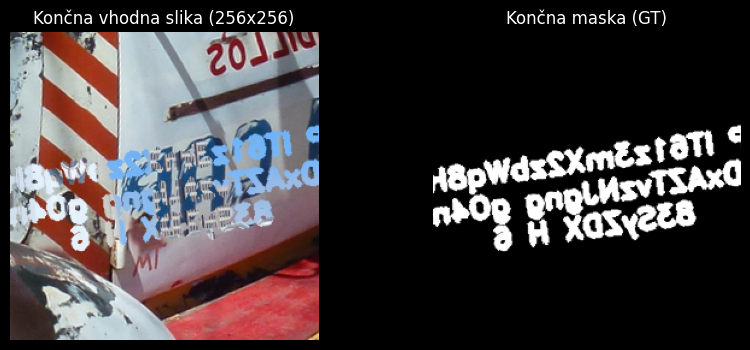

Image: (256, 256, 3)
Mask : (256, 256, 1)


In [9]:
# TEST 5: Končni center crop na 256x256

start = (GEN_SIZE - IMAGE_SIZE) // 2
end = start + IMAGE_SIZE

final_img = composed[start:end, start:end] / 255.0
final_mask = mask_aug[start:end, start:end]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title("Končna vhodna slika (256x256)")
plt.imshow(final_img[..., ::-1])
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Končna maska (GT)")
plt.imshow(final_mask[:, :, 0], cmap="gray")
plt.axis("off")

plt.show()

print("Image:", final_img.shape)
print("Mask :", final_mask.shape)

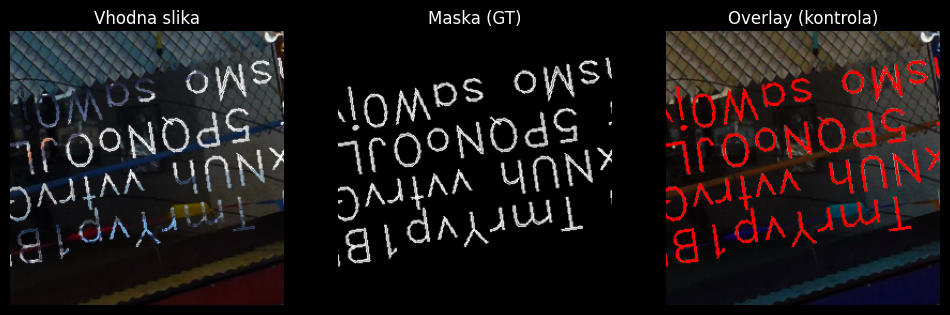

In [10]:
# TEST 6: generate_sample – vse v enem

img, msk = generate_sample(bg_path, tx_path)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Vhodna slika")
plt.imshow(img[..., ::-1])
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Maska (GT)")
plt.imshow(msk[:, :, 0], cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Overlay (kontrola)")
overlay = img.copy()
overlay[msk[:, :, 0] > 0.5] = [1, 0, 0]
plt.imshow(overlay)
plt.axis("off")

plt.show()


In [11]:
DATASET_PATH_TRAIN = "datasets/DIV2K/DIV2K_train_HR"
DATASET_PATH_TEST = "datasets/DIV2K/DIV2K_valid_HR"

In [12]:
from Model import TextSegmentationDataset

✓ Loaded existing dataset checkpoint (on_the_fly mode)
Dataset length: 100

Testing same index twice (should show different augmentations):

Call 1:
  Image: torch.Size([3, 256, 256]) [0.000, 0.902]
  Mask:  torch.Size([1, 256, 256]) [0.000, 1.000]
  Mask sum: 18440

Call 2:
  Image: torch.Size([3, 256, 256]) [0.000, 0.964]
  Mask:  torch.Size([1, 256, 256]) [0.000, 1.000]
  Mask sum: 11746


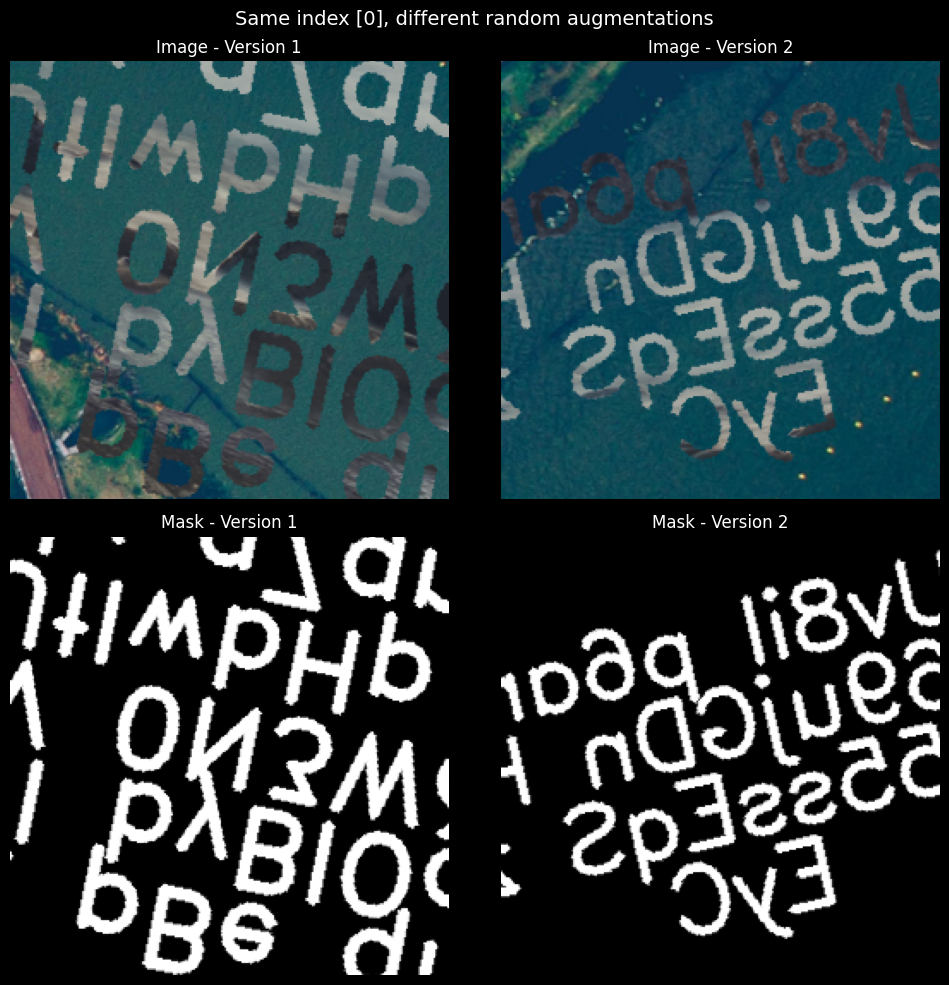

In [13]:
# Cell 1: Test on_the_fly mode (fixed pairs, random augmentations)
dataset_fly = TextSegmentationDataset(
    image_dir=DATASET_PATH_TRAIN,
    checkpoint_dir='checkpoints/dataset_fly',
    length=100,
    mode='on_the_fly'
)

print(f"Dataset length: {len(dataset_fly)}")
print("\nTesting same index twice (should show different augmentations):")

# Get two different augmented versions
imgs = []
masks = []
for i in range(2):
    img, mask = dataset_fly[0]
    imgs.append(img)
    masks.append(mask)
    print(f"\nCall {i + 1}:")
    print(f"  Image: {img.shape} [{img.min():.3f}, {img.max():.3f}]")
    print(f"  Mask:  {mask.shape} [{mask.min():.3f}, {mask.max():.3f}]")
    print(f"  Mask sum: {mask.sum().item():.0f}")

# Visualize both versions side-by-side
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].imshow(imgs[0].permute(1, 2, 0))
axes[0, 0].set_title("Image - Version 1")
axes[0, 0].axis('off')

axes[0, 1].imshow(imgs[1].permute(1, 2, 0))
axes[0, 1].set_title("Image - Version 2")
axes[0, 1].axis('off')

axes[1, 0].imshow(masks[0][0], cmap='gray')
axes[1, 0].set_title("Mask - Version 1")
axes[1, 0].axis('off')

axes[1, 1].imshow(masks[1][0], cmap='gray')
axes[1, 1].set_title("Mask - Version 2")
axes[1, 1].axis('off')

plt.suptitle("Same index [0], different random augmentations", fontsize=14)
plt.tight_layout()
plt.show()

✓ Random mode: picking from 800 images
Dataset length: 100

Testing same index twice (should show completely different samples):

Call 1:
  Image: torch.Size([3, 256, 256]) [0.001, 1.000]
  Mask:  torch.Size([1, 256, 256]) [0.000, 1.000]
  Mask sum: 7718

Call 2:
  Image: torch.Size([3, 256, 256]) [0.000, 1.000]
  Mask:  torch.Size([1, 256, 256]) [0.000, 1.000]
  Mask sum: 14105


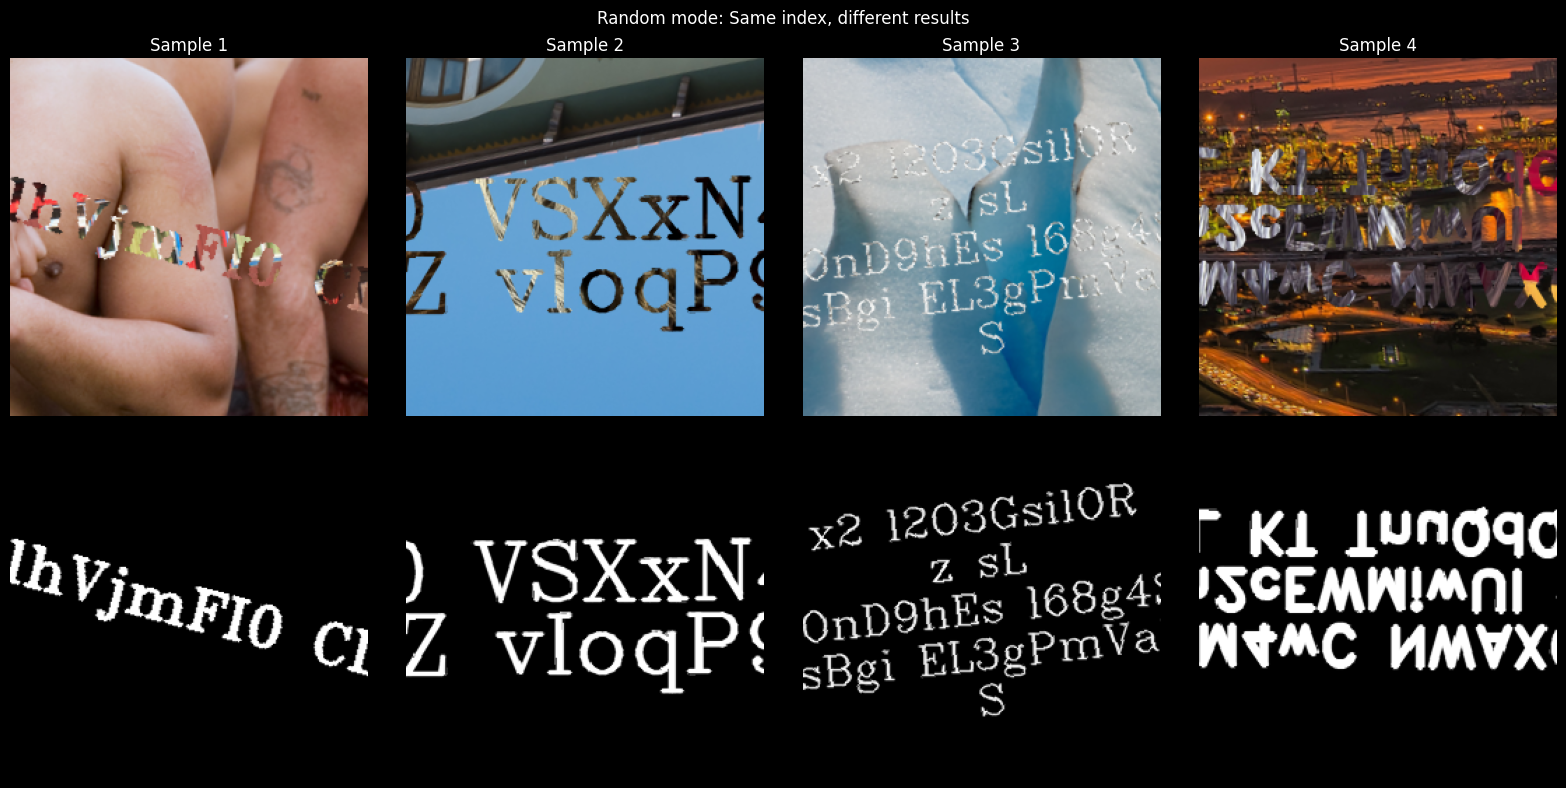

In [14]:
# Cell 2: Test random mode (fully random pairs and augmentations)
dataset_random = TextSegmentationDataset(
    image_dir=DATASET_PATH_TRAIN,
    checkpoint_dir='checkpoints/dataset_random',
    length=100,
    mode='random'
)

print(f"Dataset length: {len(dataset_random)}")
print("\nTesting same index twice (should show completely different samples):")

for i in range(2):
    img, mask = dataset_random[0]
    print(f"\nCall {i + 1}:")
    print(f"  Image: {img.shape} [{img.min():.3f}, {img.max():.3f}]")
    print(f"  Mask:  {mask.shape} [{mask.min():.3f}, {mask.max():.3f}]")
    print(f"  Mask sum: {mask.sum().item():.0f}")

# Visualize multiple samples
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    img, mask = dataset_random[0]
    axes[0, i].imshow(img.permute(1, 2, 0))
    axes[0, i].set_title(f"Sample {i + 1}")
    axes[0, i].axis('off')
    axes[1, i].imshow(mask[0], cmap='gray')
    axes[1, i].axis('off')
plt.suptitle("Random mode: Same index, different results")
plt.tight_layout()
plt.show()

✓ Loaded existing dataset checkpoint (pregenerated mode)
Dataset length: 100

Testing same index twice (should be IDENTICAL):

Call 1:
  Image: torch.Size([3, 256, 256]) [0.003, 1.000]
  Mask:  torch.Size([1, 256, 256]) [0.000, 1.000]
  Mask sum: 13789

Call 2:
  Image: torch.Size([3, 256, 256]) [0.003, 1.000]
  Mask:  torch.Size([1, 256, 256]) [0.000, 1.000]
  Mask sum: 13789

Images identical: True
Masks identical: True


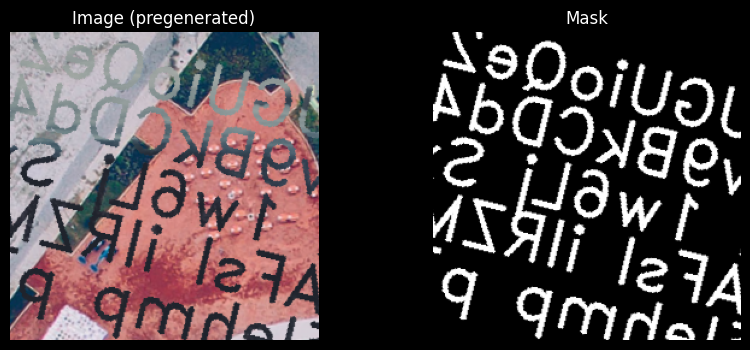

In [15]:
# Cell 3: Test pregenerated mode (fixed samples)
dataset_pre = TextSegmentationDataset(
    image_dir=DATASET_PATH_TRAIN,
    checkpoint_dir='checkpoints/dataset_pre',
    length=100,
    mode='pregenerated'
)

print(f"Dataset length: {len(dataset_pre)}")
print("\nTesting same index twice (should be IDENTICAL):")

for i in range(2):
    img, mask = dataset_pre[0]
    print(f"\nCall {i + 1}:")
    print(f"  Image: {img.shape} [{img.min():.3f}, {img.max():.3f}]")
    print(f"  Mask:  {mask.shape} [{mask.min():.3f}, {mask.max():.3f}]")
    print(f"  Mask sum: {mask.sum().item():.0f}")

# Verify reproducibility
img1, mask1 = dataset_pre[0]
img2, mask2 = dataset_pre[0]
print(f"\nImages identical: {torch.equal(img1, img2)}")
print(f"Masks identical: {torch.equal(mask1, mask2)}")

# Visualize
img, mask = dataset_pre[0]
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("Image (pregenerated)")
plt.imshow(img.permute(1, 2, 0))
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title("Mask")
plt.imshow(mask[0], cmap='gray')
plt.axis('off')
plt.show()

In [27]:
import torchinfo
from Model import UNetTextSegmentation

batch_size = 16

model = UNetTextSegmentation()
torchinfo.summary(model, (batch_size, 3, IMAGE_SIZE, IMAGE_SIZE))


Layer (type:depth-idx)                   Output Shape              Param #
UNetTextSegmentation                     [16, 1, 256, 256]         --
├─DownBlock: 1-1                         [16, 32, 256, 256]        --
│    └─DoubleConv: 2-1                   [16, 32, 256, 256]        --
│    │    └─Sequential: 3-1              [16, 32, 256, 256]        10,272
│    └─MaxPool2d: 2-2                    [16, 32, 128, 128]        --
├─DownBlock: 1-2                         [16, 64, 128, 128]        --
│    └─DoubleConv: 2-3                   [16, 64, 128, 128]        --
│    │    └─Sequential: 3-2              [16, 64, 128, 128]        55,680
│    └─MaxPool2d: 2-4                    [16, 64, 64, 64]          --
├─DownBlock: 1-3                         [16, 128, 64, 64]         --
│    └─DoubleConv: 2-5                   [16, 128, 64, 64]         --
│    │    └─Sequential: 3-3              [16, 128, 64, 64]         221,952
│    └─MaxPool2d: 2-6                    [16, 128, 32, 32]         --
├─

In [26]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model.to(DEVICE)

x = torch.randn(1, 3, 256, 256).to(DEVICE)
y = model(x)

print("Output shape:", y.shape)

Output shape: torch.Size([1, 1, 256, 256])
